# Mutational profile

In [2]:
import pandas as pd
import os
from bgreference import hg38
import itertools
from collections import defaultdict
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pybedtools
import json
#from aux_functions import df_to_dict

CHANNELS = ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', 'A[C>G]C',
            'A[C>G]G', 'A[C>G]T', 'A[C>T]A', 'A[C>T]C', 'A[C>T]G', 'A[C>T]T',
            'A[T>A]A', 'A[T>A]C', 'A[T>A]G', 'A[T>A]T', 'A[T>C]A', 'A[T>C]C',
            'A[T>C]G', 'A[T>C]T', 'A[T>G]A', 'A[T>G]C', 'A[T>G]G', 'A[T>G]T',
            'C[C>A]A', 'C[C>A]C', 'C[C>A]G', 'C[C>A]T', 'C[C>G]A', 'C[C>G]C',
            'C[C>G]G', 'C[C>G]T', 'C[C>T]A', 'C[C>T]C', 'C[C>T]G', 'C[C>T]T',
            'C[T>A]A', 'C[T>A]C', 'C[T>A]G', 'C[T>A]T', 'C[T>C]A', 'C[T>C]C',
            'C[T>C]G', 'C[T>C]T', 'C[T>G]A', 'C[T>G]C', 'C[T>G]G', 'C[T>G]T',
            'G[C>A]A', 'G[C>A]C', 'G[C>A]G', 'G[C>A]T', 'G[C>G]A', 'G[C>G]C',
            'G[C>G]G', 'G[C>G]T', 'G[C>T]A', 'G[C>T]C', 'G[C>T]G', 'G[C>T]T',
            'G[T>A]A', 'G[T>A]C', 'G[T>A]G', 'G[T>A]T', 'G[T>C]A', 'G[T>C]C',
            'G[T>C]G', 'G[T>C]T', 'G[T>G]A', 'G[T>G]C', 'G[T>G]G', 'G[T>G]T',
            'T[C>A]A', 'T[C>A]C', 'T[C>A]G', 'T[C>A]T', 'T[C>G]A', 'T[C>G]C',
            'T[C>G]G', 'T[C>G]T', 'T[C>T]A', 'T[C>T]C', 'T[C>T]G', 'T[C>T]T',
            'T[T>A]A', 'T[T>A]C', 'T[T>A]G', 'T[T>A]T', 'T[T>C]A', 'T[T>C]C',
            'T[T>C]G', 'T[T>C]T', 'T[T>G]A', 'T[T>G]C', 'T[T>G]G', 'T[T>G]T']


In [3]:
samples_sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
exclude_pts = ['pt2','pt10','pt16','pt20']
samples_sjd_dict = {k:v for k,v in samples_sjd_dict.items() if k not in exclude_pts}
samples_target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
samples_target_dict = {k:v for k,v in samples_target_dict.items() if 'normal' in v.keys()}
samples_stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))
bad_quality_samples = ['SJ032047','SJ033133']
xenograft = ['SJ063832']
no_age_data = ['SJ014754']
exclude_pts =  bad_quality_samples + xenograft+ no_age_data
samples_stjude_dict = {k:v for k,v in samples_stjude_dict.items() if k not in exclude_pts}
samples_pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = samples_sjd_dict | samples_target_dict | samples_stjude_dict | samples_pmc_dict

In [4]:
channels = [c[0]+c[2]+c[6]+c[4] for c in CHANNELS]
print(channels)

['ACAA', 'ACCA', 'ACGA', 'ACTA', 'ACAG', 'ACCG', 'ACGG', 'ACTG', 'ACAT', 'ACCT', 'ACGT', 'ACTT', 'ATAA', 'ATCA', 'ATGA', 'ATTA', 'ATAC', 'ATCC', 'ATGC', 'ATTC', 'ATAG', 'ATCG', 'ATGG', 'ATTG', 'CCAA', 'CCCA', 'CCGA', 'CCTA', 'CCAG', 'CCCG', 'CCGG', 'CCTG', 'CCAT', 'CCCT', 'CCGT', 'CCTT', 'CTAA', 'CTCA', 'CTGA', 'CTTA', 'CTAC', 'CTCC', 'CTGC', 'CTTC', 'CTAG', 'CTCG', 'CTGG', 'CTTG', 'GCAA', 'GCCA', 'GCGA', 'GCTA', 'GCAG', 'GCCG', 'GCGG', 'GCTG', 'GCAT', 'GCCT', 'GCGT', 'GCTT', 'GTAA', 'GTCA', 'GTGA', 'GTTA', 'GTAC', 'GTCC', 'GTGC', 'GTTC', 'GTAG', 'GTCG', 'GTGG', 'GTTG', 'TCAA', 'TCCA', 'TCGA', 'TCTA', 'TCAG', 'TCCG', 'TCGG', 'TCTG', 'TCAT', 'TCCT', 'TCGT', 'TCTT', 'TTAA', 'TTCA', 'TTGA', 'TTTA', 'TTAC', 'TTCC', 'TTGC', 'TTTC', 'TTAG', 'TTCG', 'TTGG', 'TTTG']


In [5]:
#GET TRINUCLEOTIDE CONTEXT OF SNVS IN PYRIMIDE REF

def get_context_rev(rw):
    '''Get nt that are in the 5' and 3' of the mutations in the reverse sequence'''
    equival_nt = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}

    pos = rw['POS']
    left, ref, right = hg38(rw['#CHROM'], pos - 1, size=3)
    alt = rw['ALT']
    
    rw['TRIPLE'] = left + '[' + ref + '>' + alt + ']' + right
    rw['TRIPLE_COM_REV'] = equival_nt[right] + '[' + equival_nt[ref] + '>' + equival_nt[alt] + ']' + equival_nt[left]
    
    if ref != rw['REF']:
        print(rw)

    return rw


def add_pyrimidine_type(df):
    '''If the nt is a purine, it gets the complementary pyrimidine'''

    dff = pd.DataFrame()

    for i, rw in df.iterrows():
        if rw['TRIPLE'] in CHANNELS:
            rw['VARIANT_TYPE'] = rw['TRIPLE']
            df_rw_T = rw.to_frame().T
            dff = pd.concat([dff,df_rw_T], ignore_index=True)
        else:
            rw['VARIANT_TYPE'] = rw['TRIPLE_COM_REV']
            df_rw_T = rw.to_frame().T
            dff = pd.concat([dff,df_rw_T], ignore_index=True)
    dff.drop(columns=['TRIPLE', 'TRIPLE_COM_REV'], inplace=True)
    return dff


def count_variant_type(df):
    '''Count the variant after obtaining all varaints in pyr-pur format'''

    count = {ctxt: 0 for ctxt in CHANNELS}

    for i, rw in df.iterrows():
        count[rw['VARIANT_TYPE']] = count[rw['VARIANT_TYPE']] + 1

    return count


def df_to_dict(df):
    '''Get dictionary with all counts in each variant type'''
    
    df.rename(columns={'CHROMOSOME': '#CHROM', 'POSITION': 'POS'}, inplace=True)
    df = df[['#CHROM', 'POS', 'REF', 'ALT']]
    df.drop_duplicates(keep='first', inplace=True)

    # make dictionary with counts centered in pyrimidines
    df = df.apply(lambda x: get_context_rev(x), axis=1)
    df = add_pyrimidine_type(df)
    count = count_variant_type(df)

    # from dict to pandas df
    df_96 = pd.DataFrame.from_dict(count, orient='index')
    df_96.reset_index(inplace=True)
    df_96.columns = ['change', 'count']

    # change to dictionary with special key annotation
    df_96[['count']] = df_96[['count']].astype(int)
    #     total = df_96['count'].sum()
    #     df_96['relative_count'] = df_96['count'].apply(lambda x: x/total)
    df_96 = df_96[['count', 'change']]
    df_96.set_index('change', inplace=True)
    df_96 = df_96.sort_index()
    dictionary_standard = df_96.to_dict()['count']

    # fill missing context with 0 counts
    for k in CHANNELS:
        if k not in dictionary_standard.keys():
            dictionary_standard[k] = 0
    return dictionary_standard

def change_dct_format(dicc):
    '''Change the format of the dictionary to be ready for the plot'''
    dicc_change = dict()
    for k, v in dicc.items():
        # split elements of channel annotation
        left = k.split("[")[0]
        ref = k.split("[")[1].split('>')[0]
        alt = k.split("]")[0].split('>')[-1]
        right = k.split("]")[-1]
        
        # write in the other format (1st substitution, 2nd context)
        new_cntxt = tuple([ref+alt, left+right])  
        dicc_change[new_cntxt] = dicc[k]
    
    dicc_sorted = OrderedDict()
    for k in mut_key_generator():
        dicc_sorted[k] = dicc_change[k]
    
    return dicc_sorted

In [6]:
def mut_key_generator():
    """

    Returns:
        Generates all possible lex sortable mutation keys
        1st component: substitution;
        2nd component: flanks

    """
    subs = ['CA', 'CG', 'CT', 'TA', 'TC', 'TG']
    for s in sorted(subs):
        for c in sorted(itertools.product(set('ACGT'), repeat=2)):
            yield tuple([s, ''.join(c)])


def minor_tick_labels():
    major_labels = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    flanks = ['AA', 'AC', 'AG', 'AT', 'CA', 'CC', 'CG', 'CT',
              'GA', 'GC', 'GG', 'GT', 'TA', 'TC', 'TG', 'TT']
    minor_labels = []
    for subs in major_labels:
        for flank in flanks:
            minor_labels.append(flank[0] + subs[0] + flank[1])
    return minor_labels


def plot_signature(profile, title=None, ax=None):
    """
    Args:
        profile: signature-like object in lexicographic order
        title: string
        ymax: float

    Returns:
        produces the signature bar plot
    """

    total = sum(profile.values())
    if abs(total - 1) > 0.01:
        profile = defaultdict(int, {k: v / total for k, v in profile.items()})
    sns.set(font_scale=1.5)
    sns.set_style('white')
    vector = np.array([profile[k] for k in sorted(mut_key_generator())])
    
    # set plot size
    fig.set_size_inches(15, 4)

    # bar plot
    barlist = ax.bar(range(96), vector)
    color_list = ['#72bcd4', 'k', 'r', '#7e7e7e', 'g', '#e6add8']
    for category in range(6):
        for i in range(16):
            barlist[category * 16 + i].set_color(color_list[category])
            
    ymax = max(vector)*1.2
    ax.set_xlim([-0.5, 96])
    ax.set_ylim([0, ymax])

    # ax.set_ylabel('subs rel freq')
    labels = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    major_ticks = np.arange(8, 8 + 16 * 5 + 1, 16)
    minor_ticks = np.arange(0.2, 96.2, 1)
    ax.tick_params(length=0, which='major', pad=20, labelsize=12)
    ax.tick_params(length=0, which='minor', pad=5, labelsize=6)
    ax.set_xticks(major_ticks, minor=False)
    ax.set_xticklabels(labels, minor=False)
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_xticklabels(minor_tick_labels(), minor=True, rotation=90)
    ax.set_title(title, fontsize=24)

# Mutational profiles per patient, tumor and caller

In [7]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

pt1 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


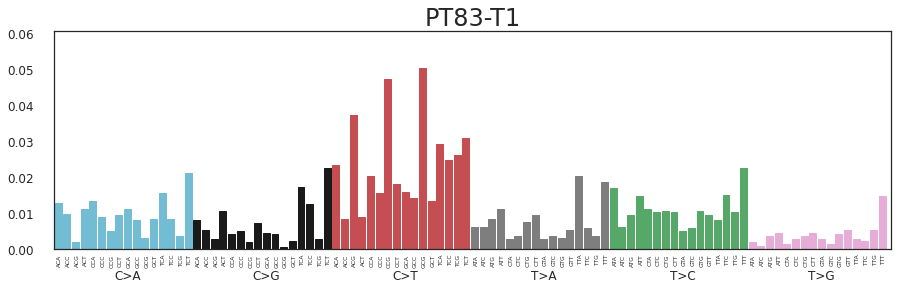

pt1 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


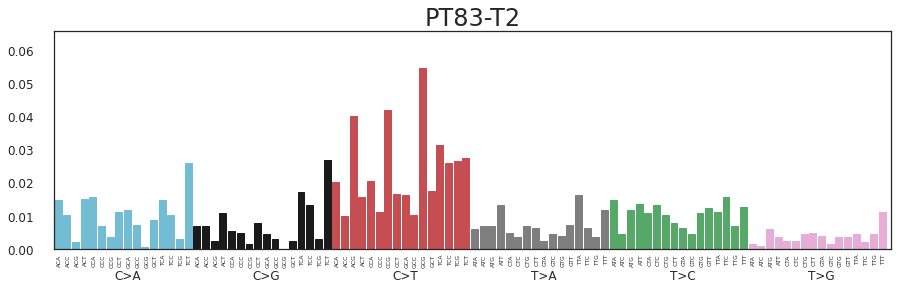

pt3 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


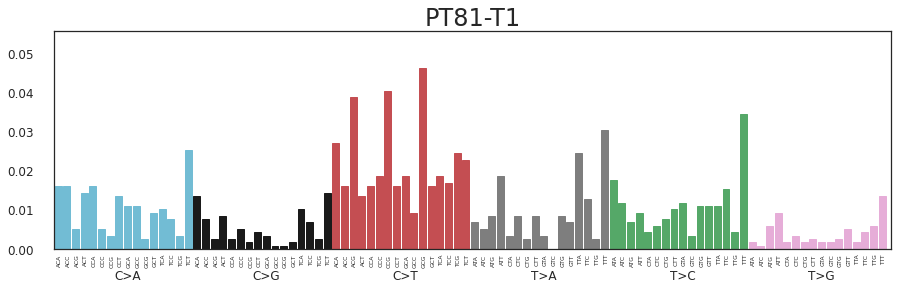

pt3 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


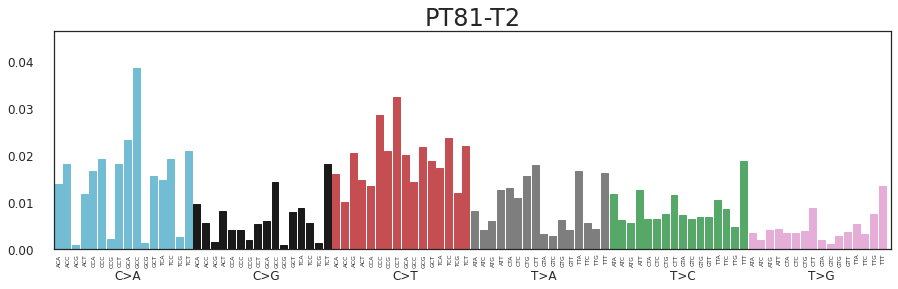

pt4 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


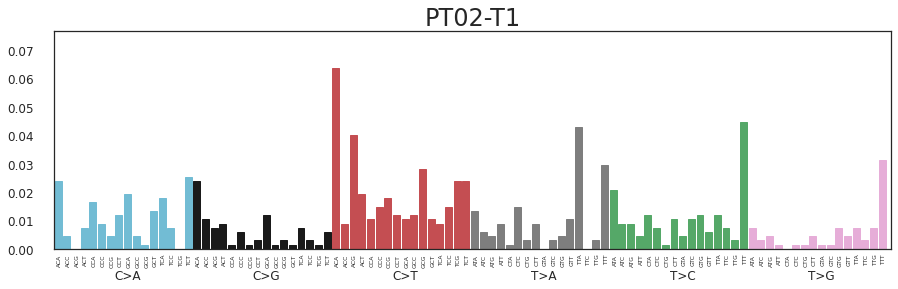

pt4 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


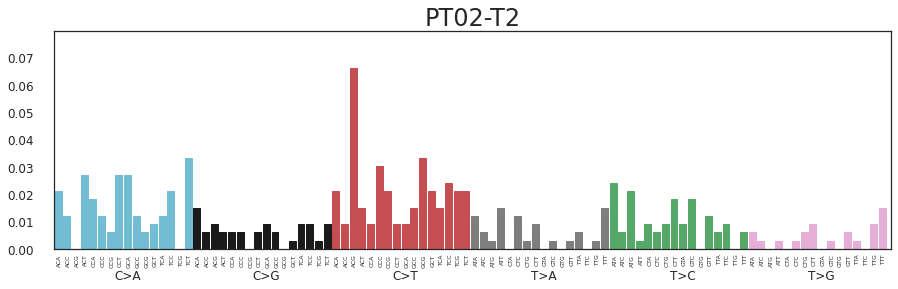

pt5 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


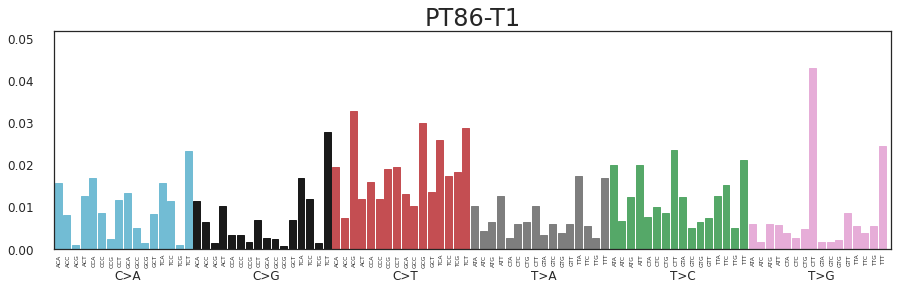

pt5 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


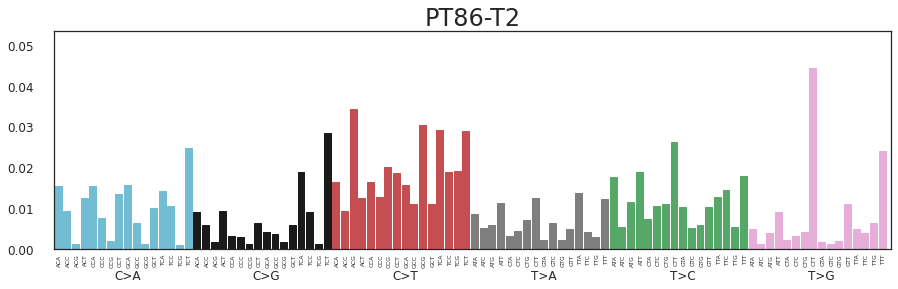

pt6 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


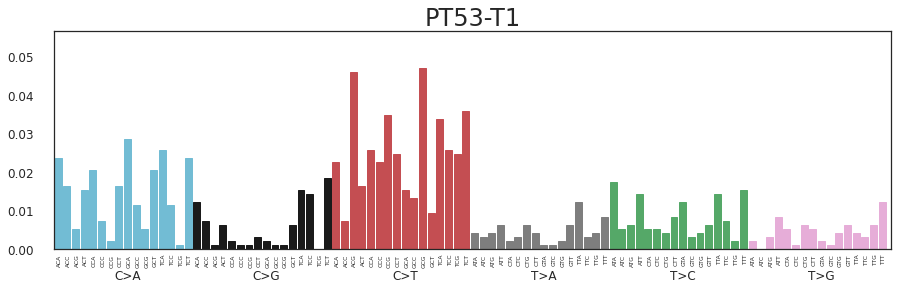

pt6 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


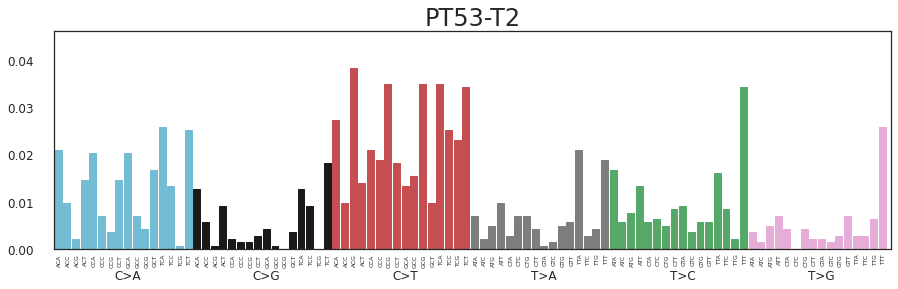

pt7 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


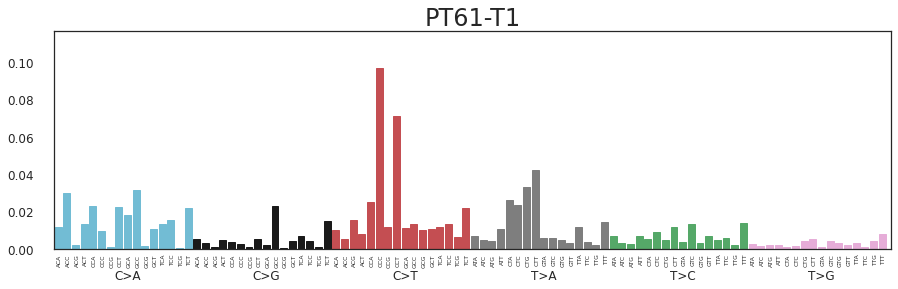

pt8 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


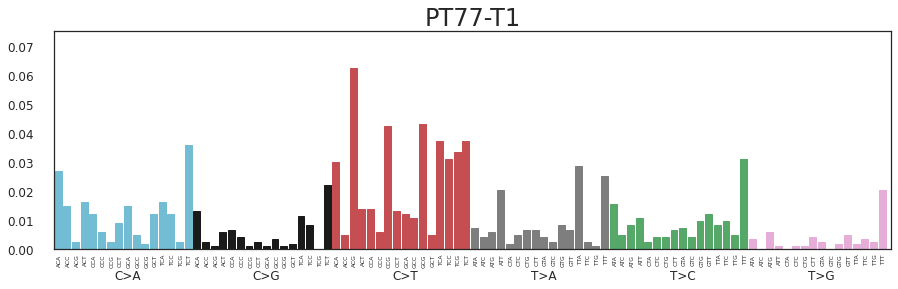

pt9 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


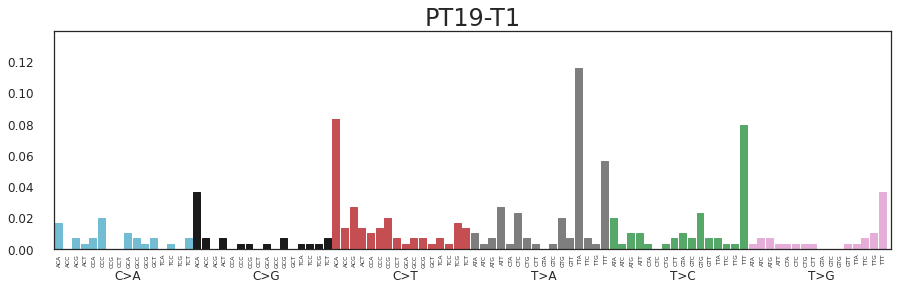

pt9 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


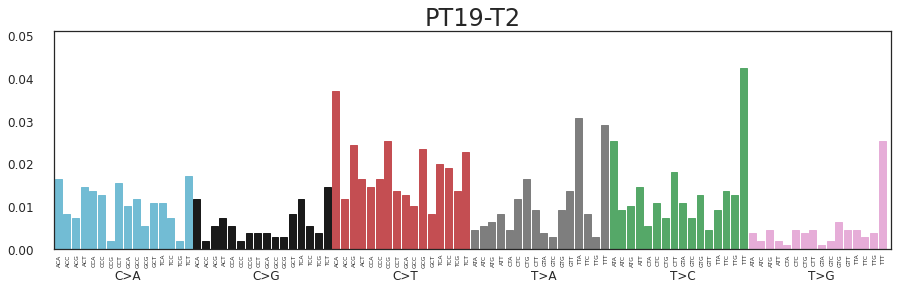

pt11 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


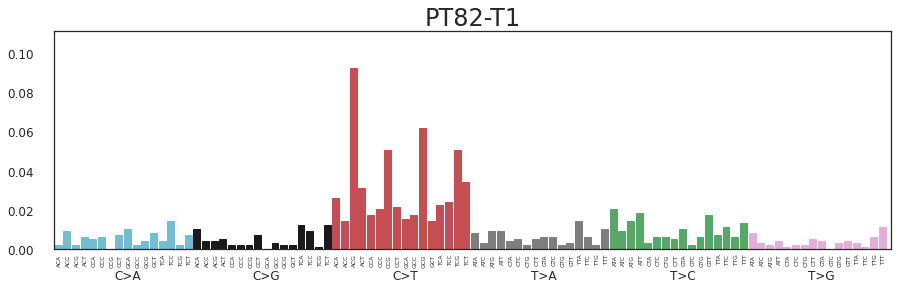

pt12 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


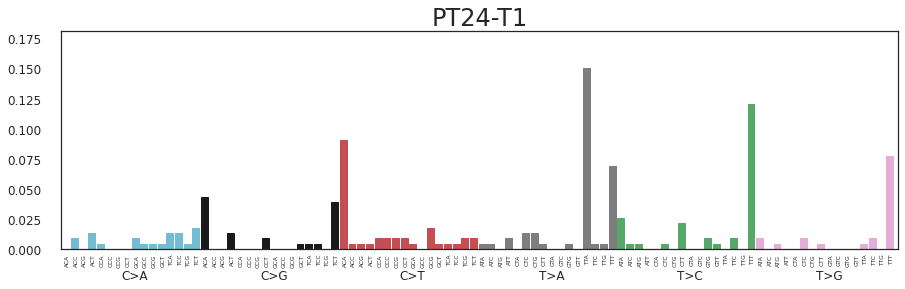

pt12 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


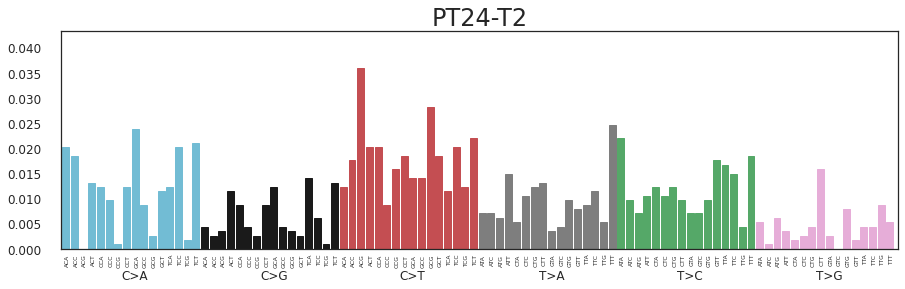

pt13 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


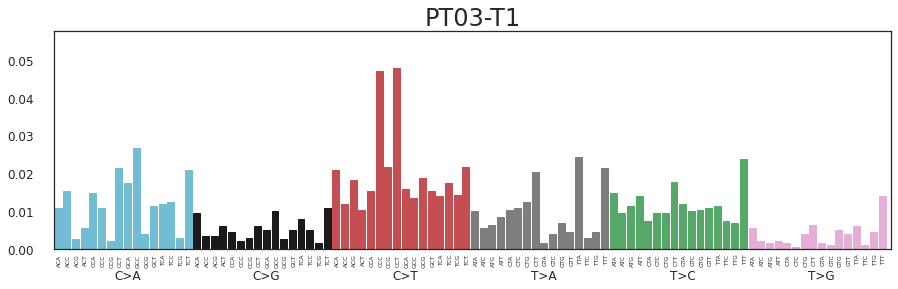

pt14 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


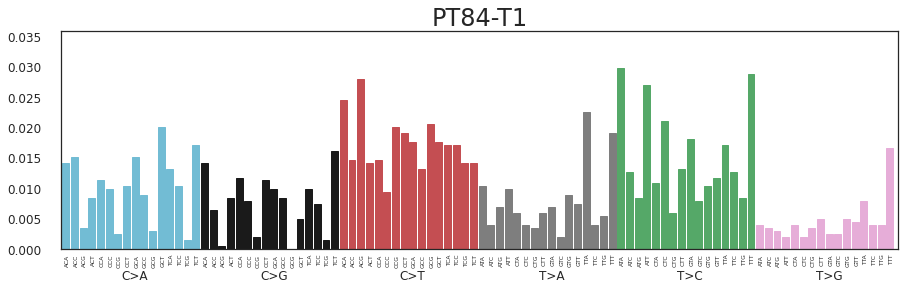

pt14 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


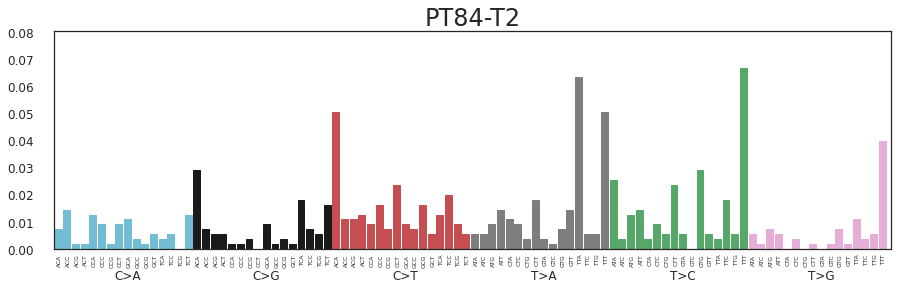

pt15 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


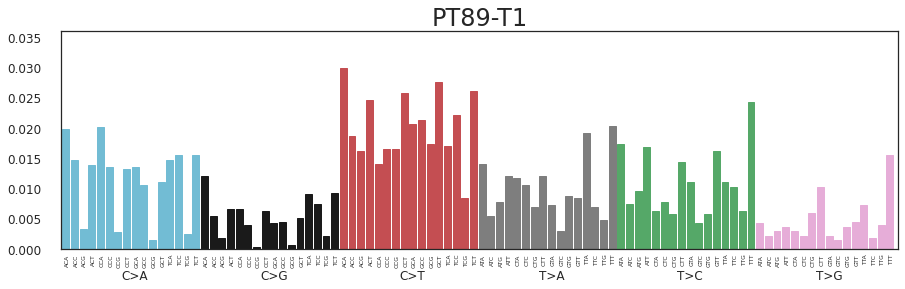

pt17 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


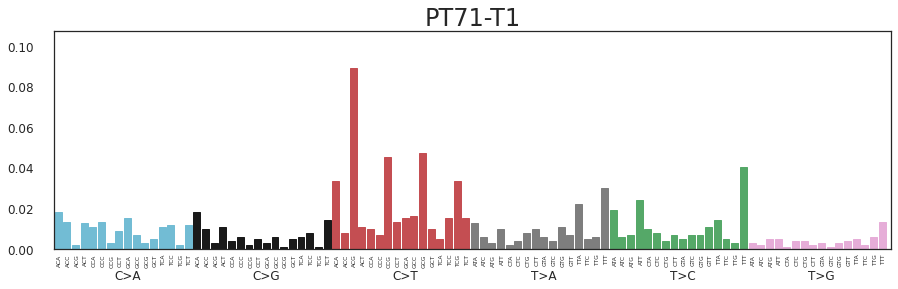

pt18 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


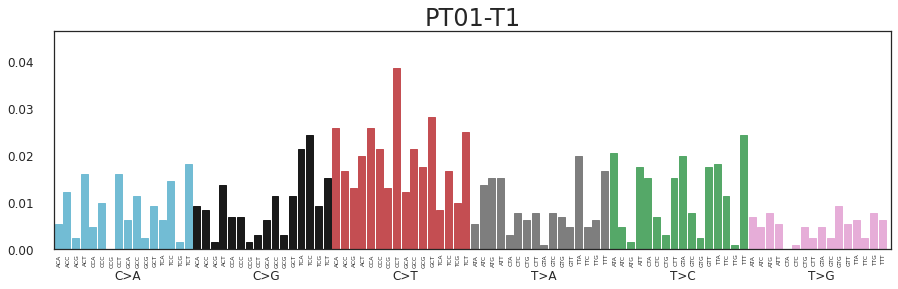

pt18 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


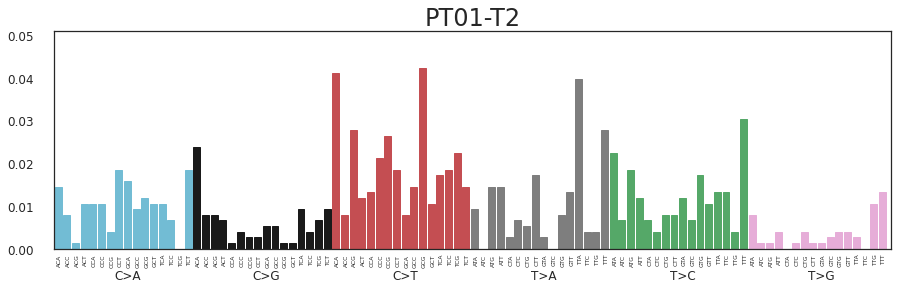

pt19 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


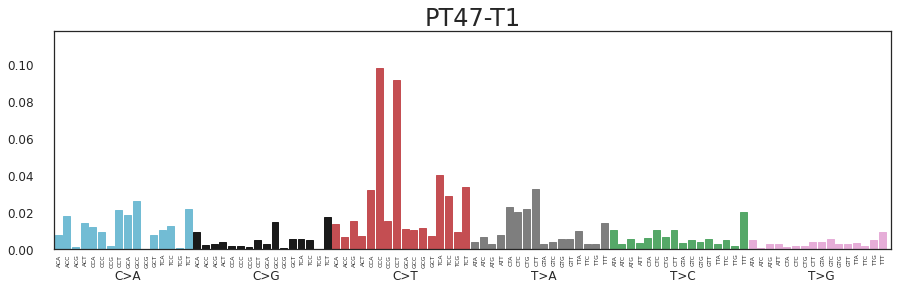

PABKLN tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


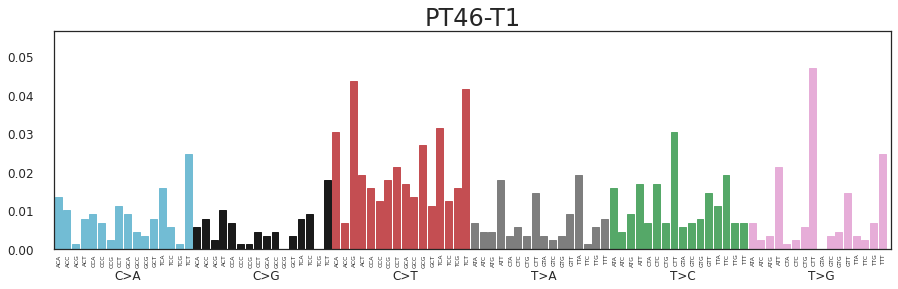

PADWRZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


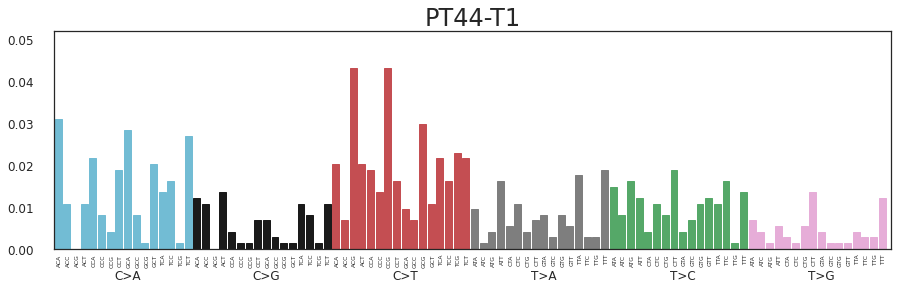

PADYZI tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


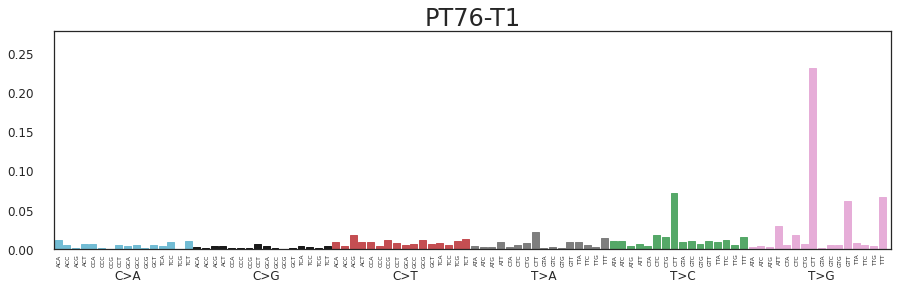

PAEHIP tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


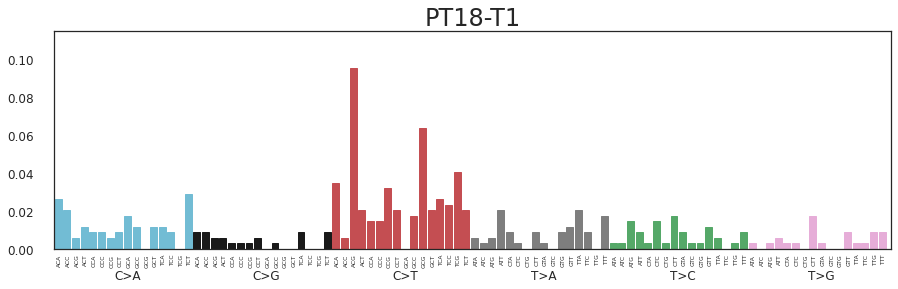

PAJLWM tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


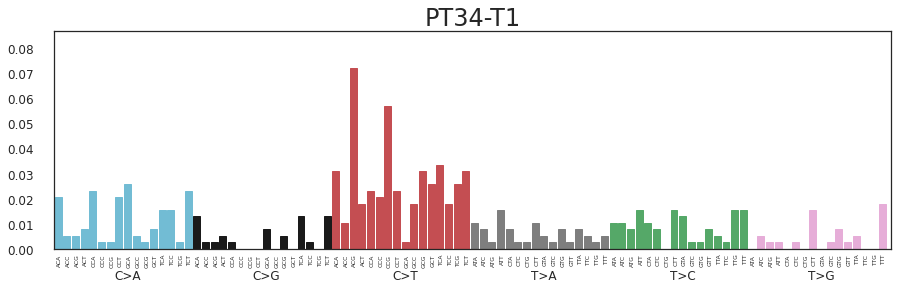

PAJMBW tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


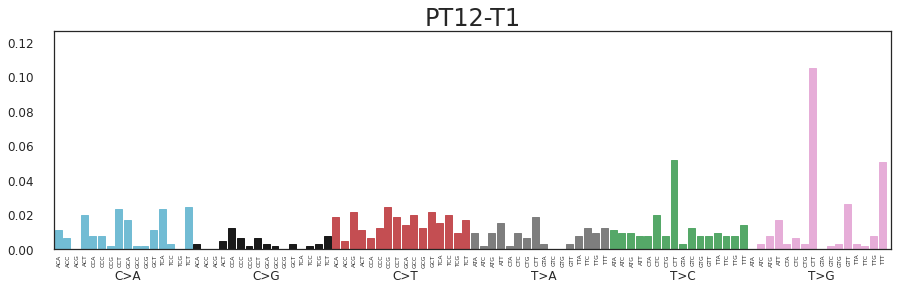

PAJMRB tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


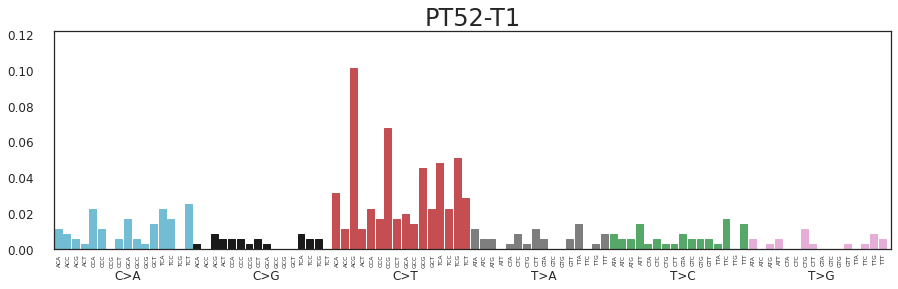

PAJNER tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


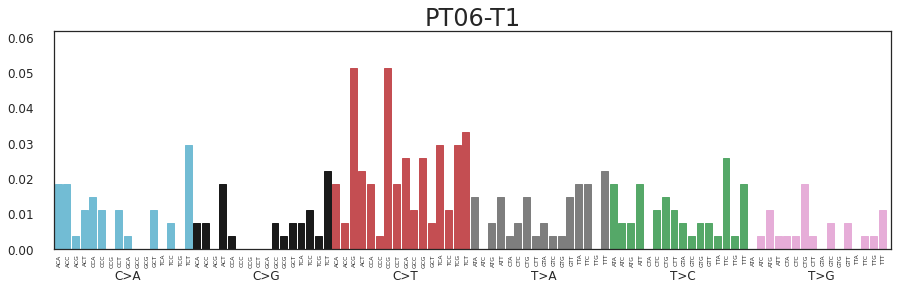

PAJNFP tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


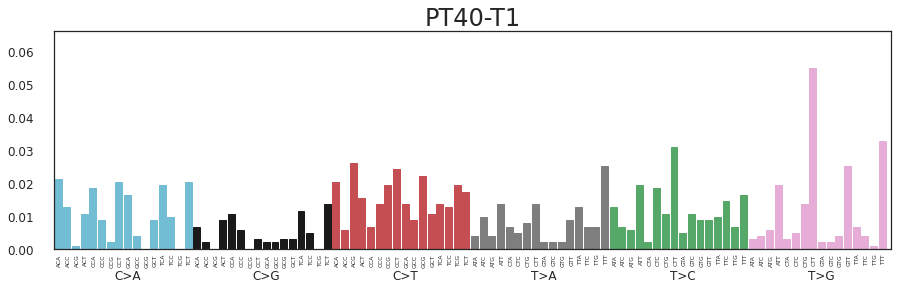

PAJNFZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


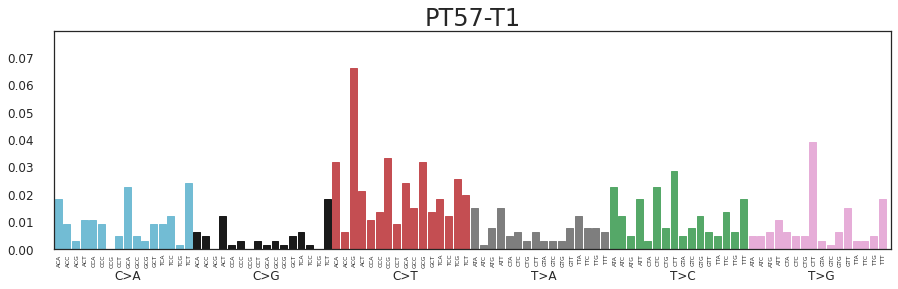

PAKHTL tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


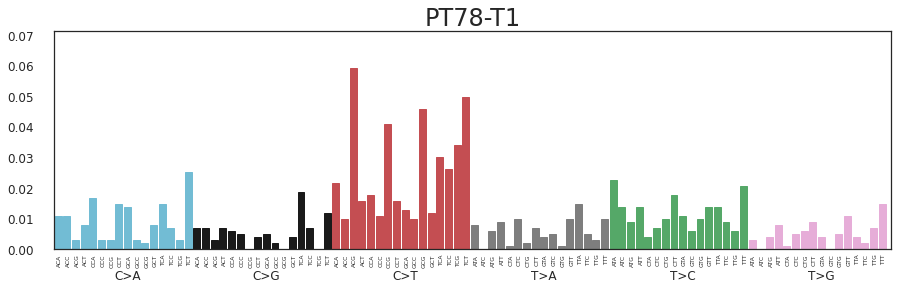

PAKLYZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


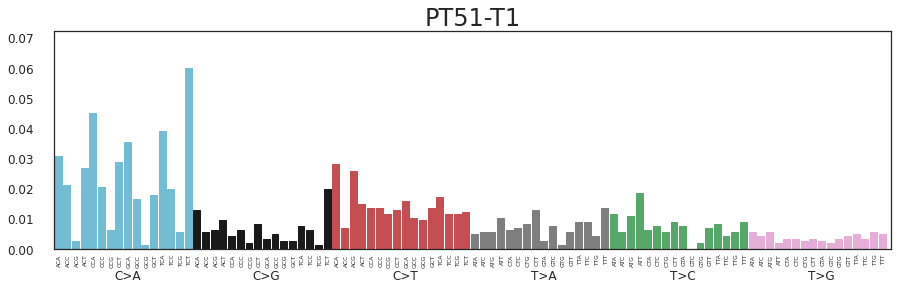

PAKTCT tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


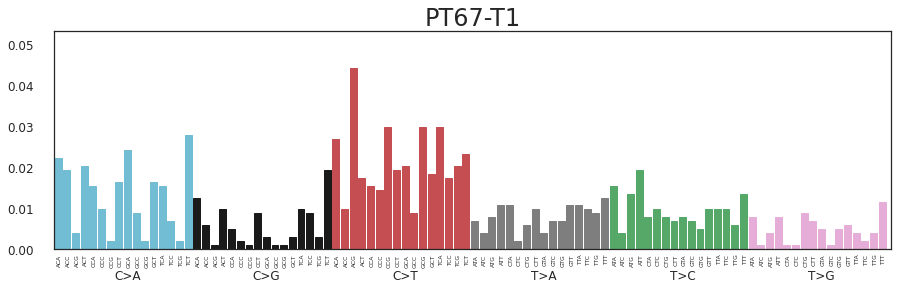

PARECB tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


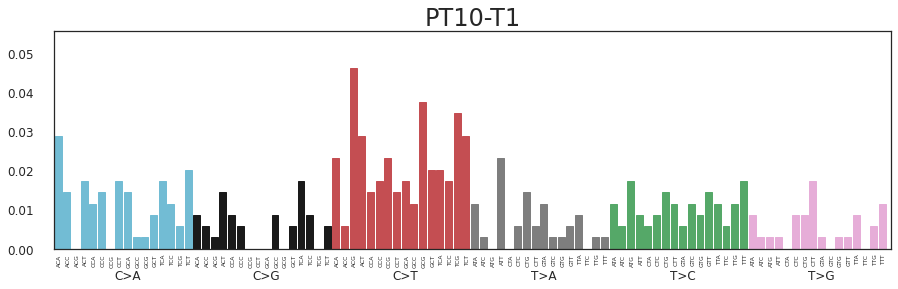

PAREWI tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


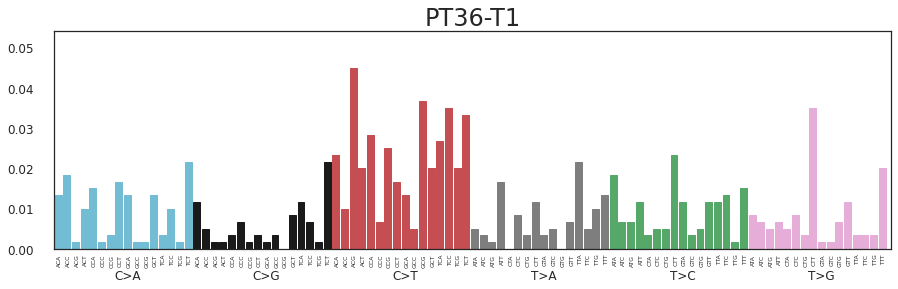

PARGRN tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


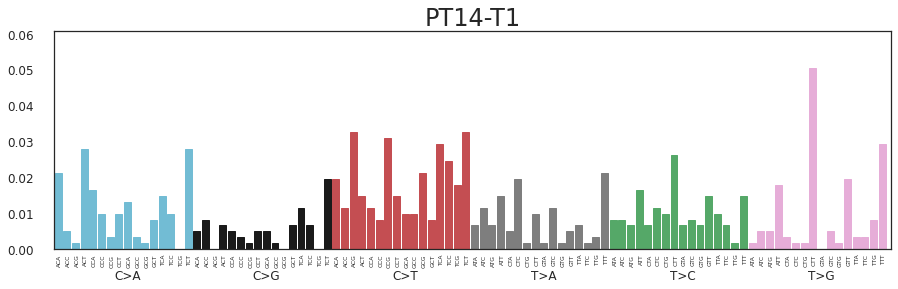

PARIRN tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


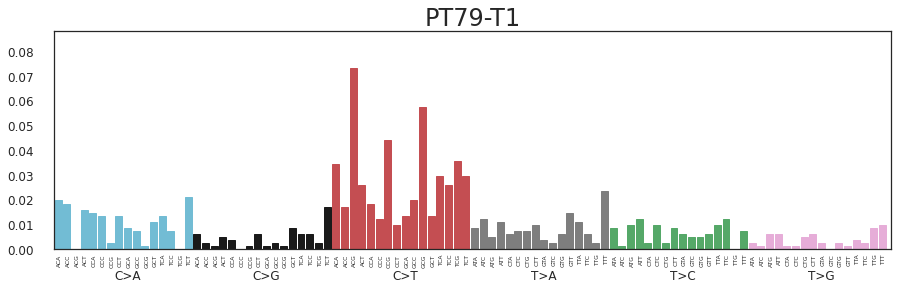

PARPFY tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


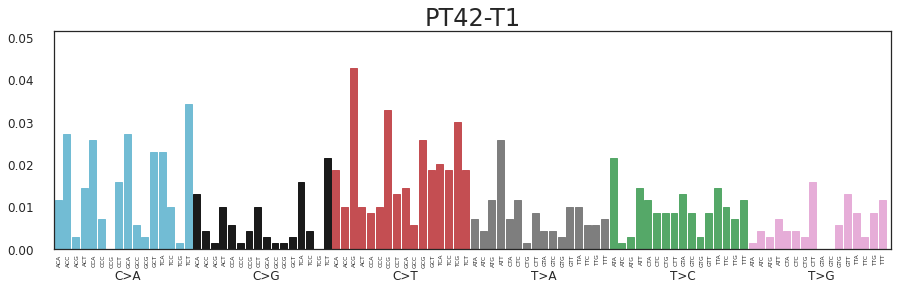

PARRCL tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


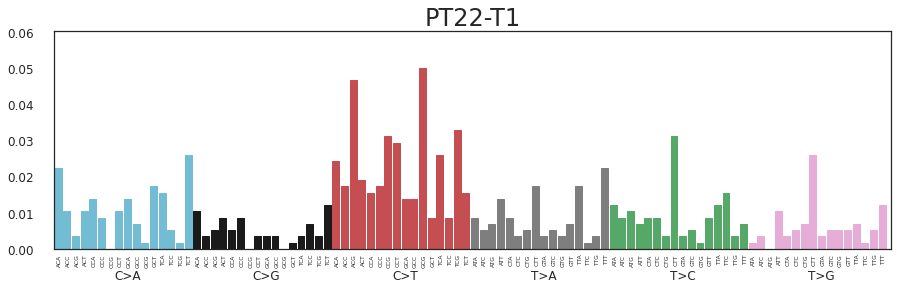

PARTKH tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


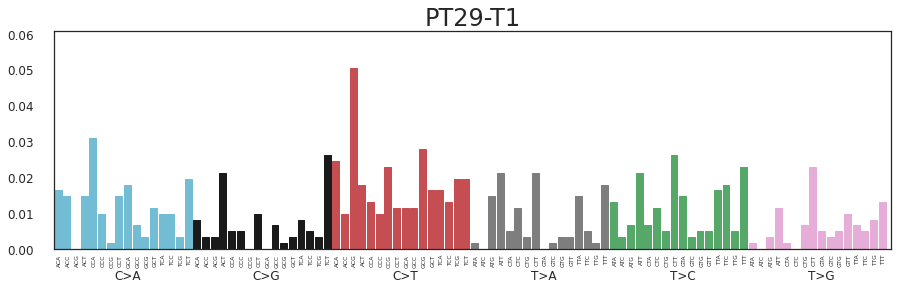

PARUGK tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


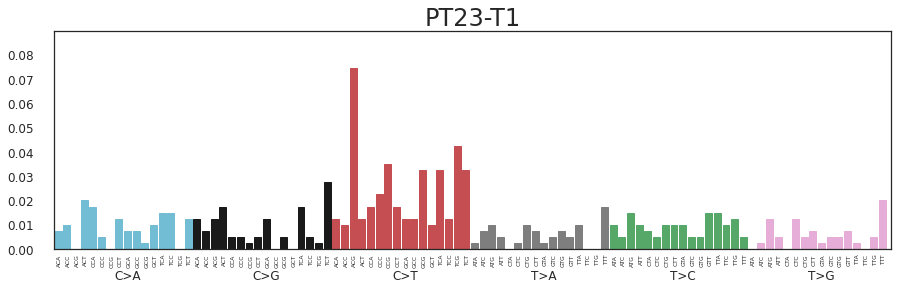

PARZBI tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


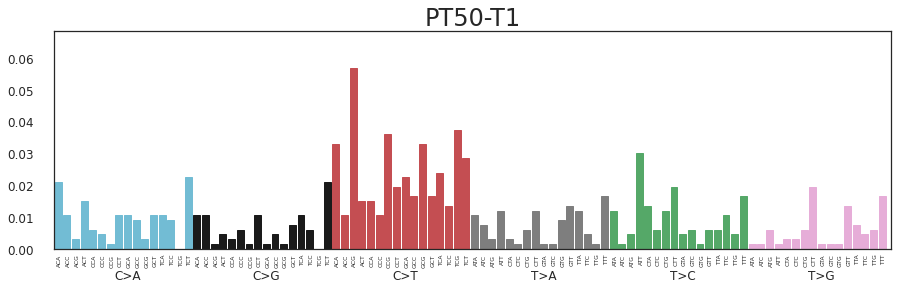

PARZRH tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


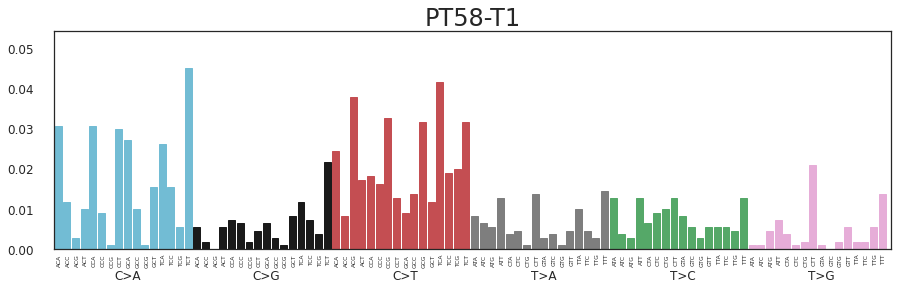

PASABD tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


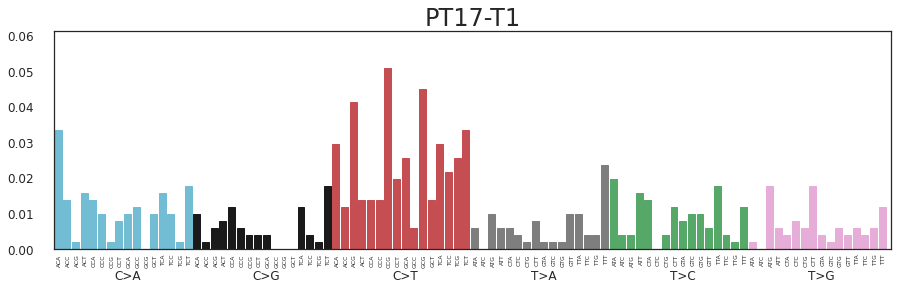

PASADZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


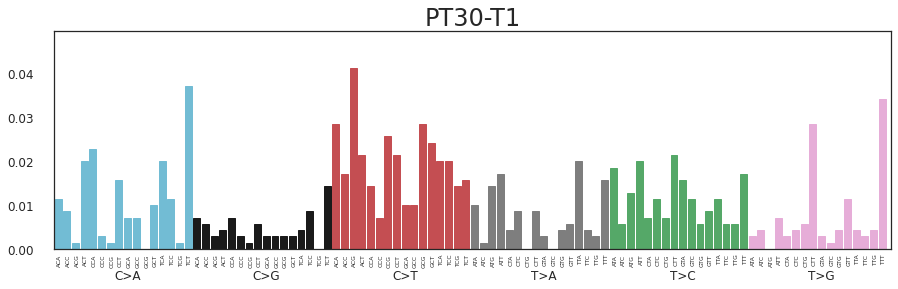

PASCDH tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


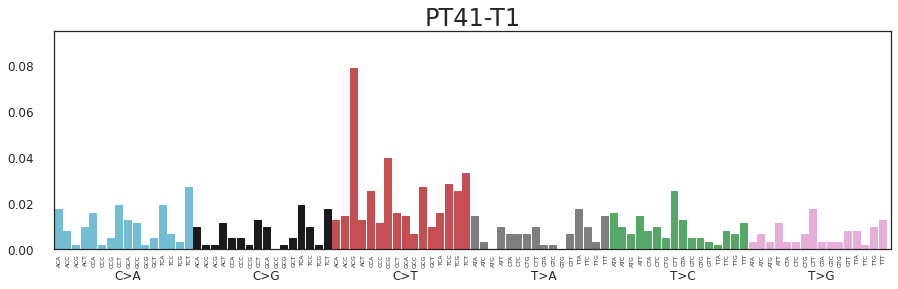

PASDLA tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


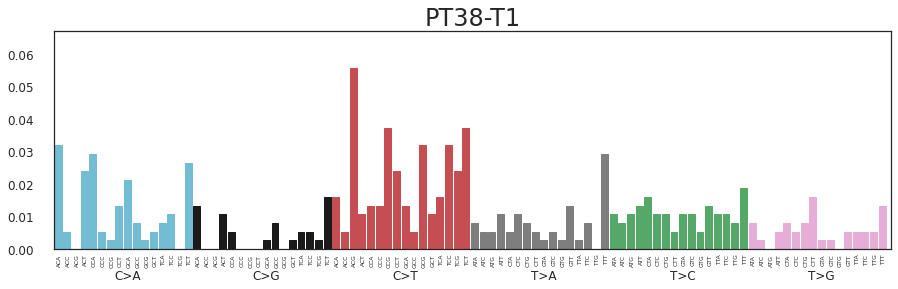

PASGCL tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


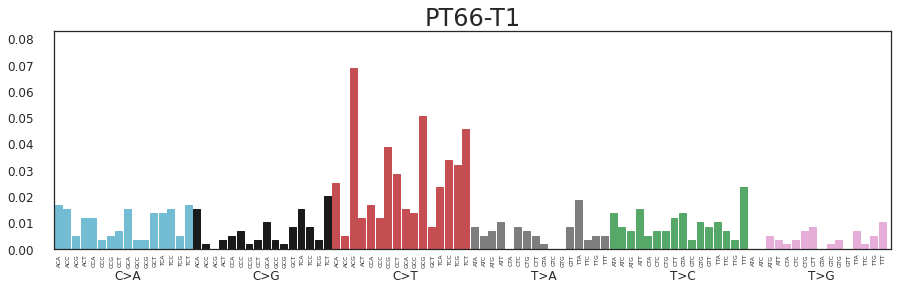

PASRHU tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


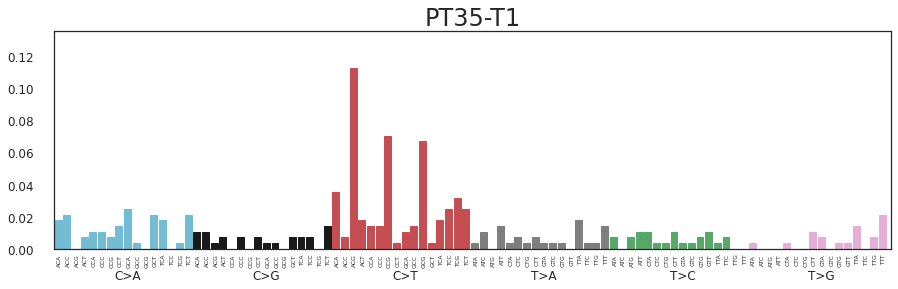

PASVDP tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


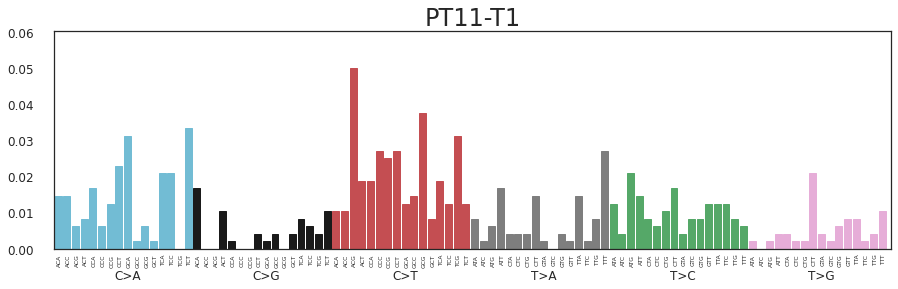

PASWZZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


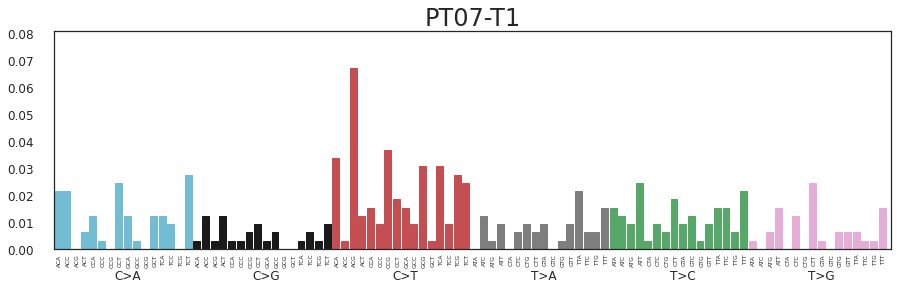

PASXNA tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


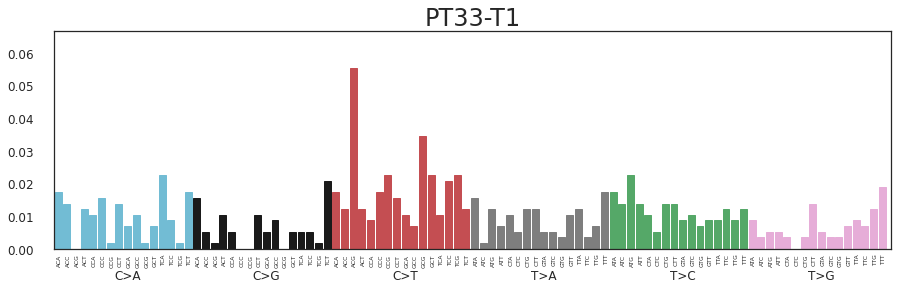

PASYNF tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


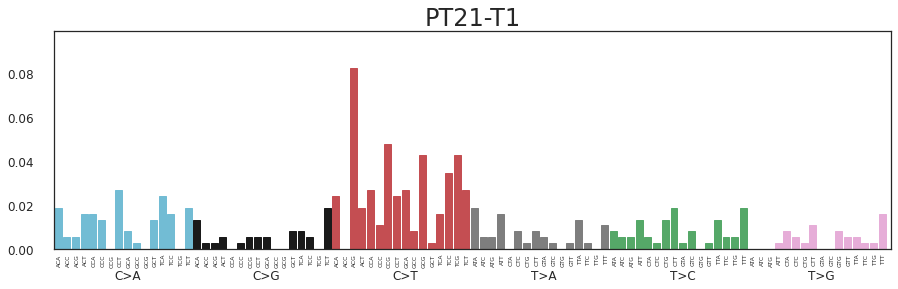

PASZYE tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


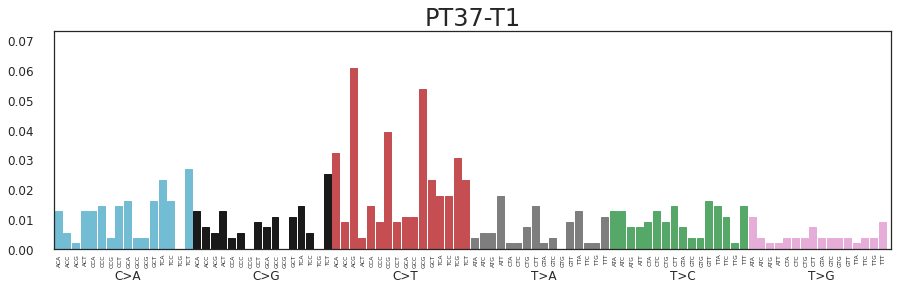

PATAFT tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


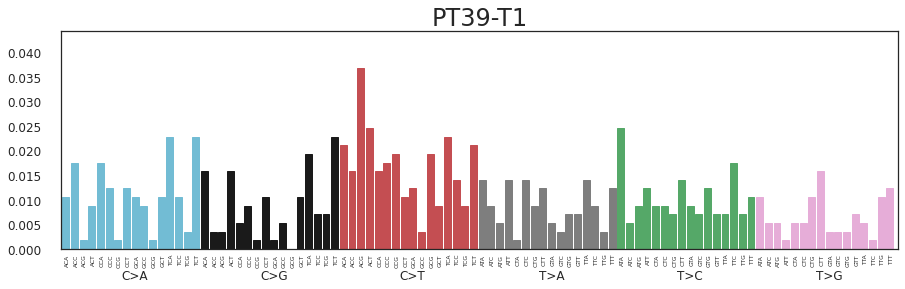

PATBLF tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


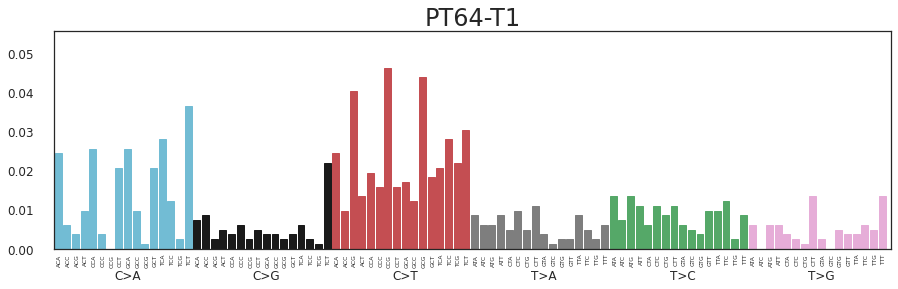

PATDVL tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


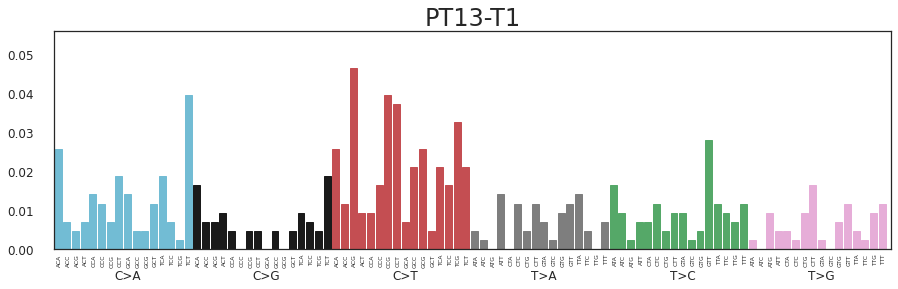

PATENH tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


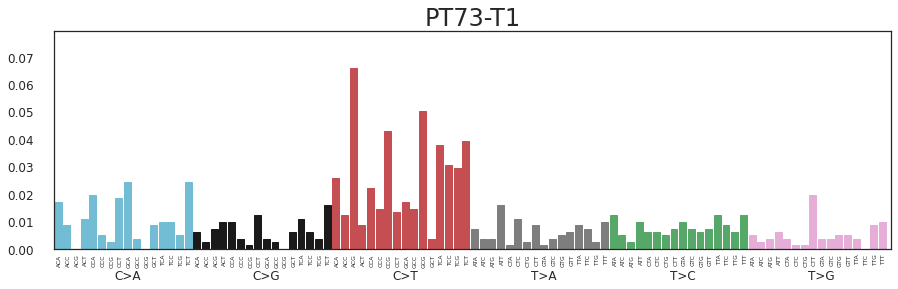

PATFXW tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


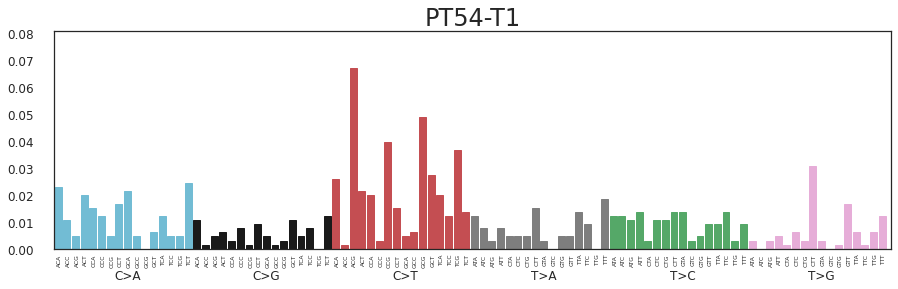

PATFZZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


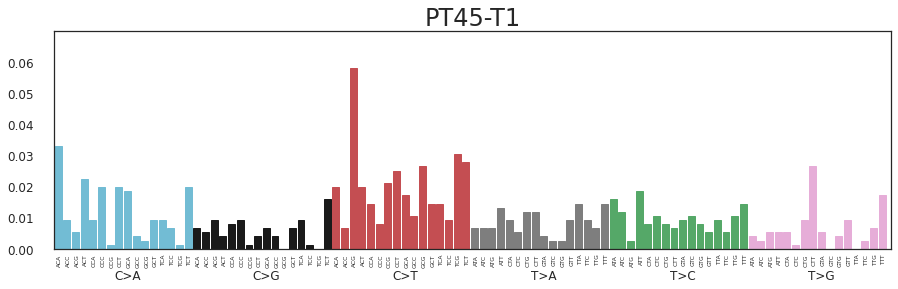

PATXEE tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


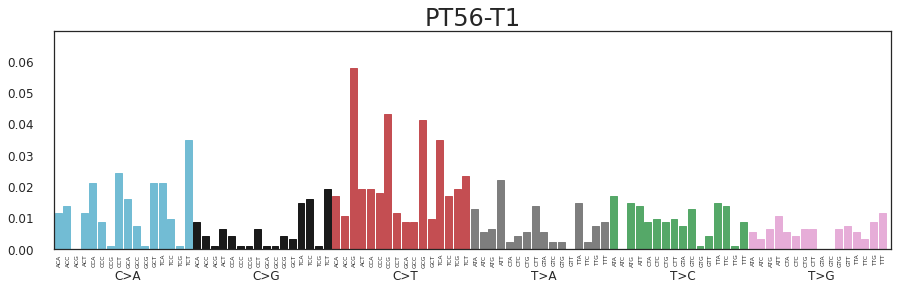

PATXKA tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


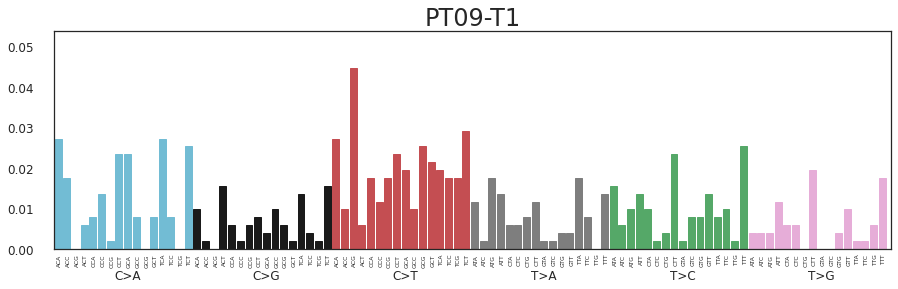

PAUCGJ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


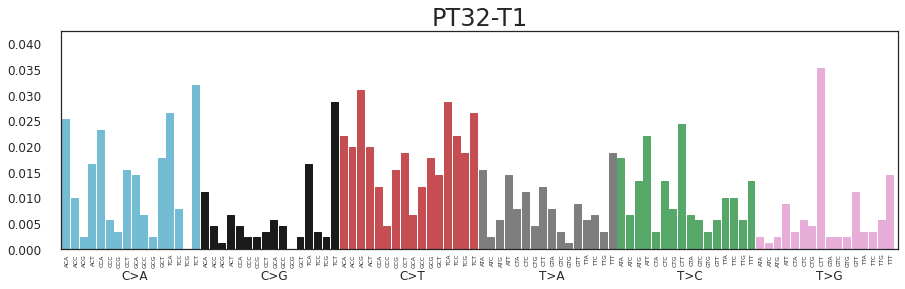

PAUDPV tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


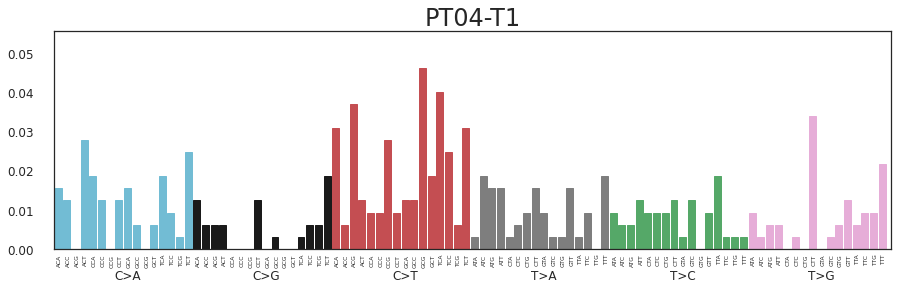

PAUEKW tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


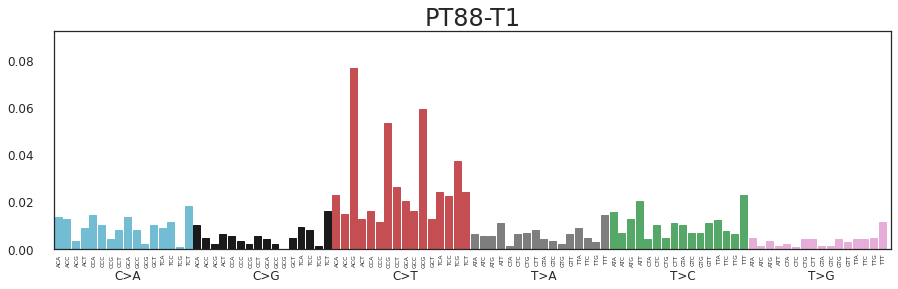

PAUFVP tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


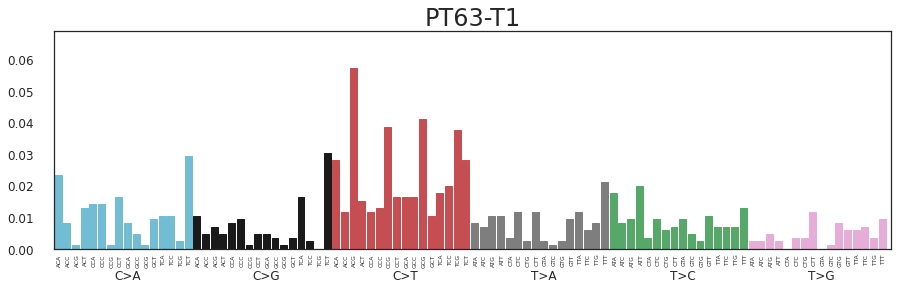

PAUGYZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


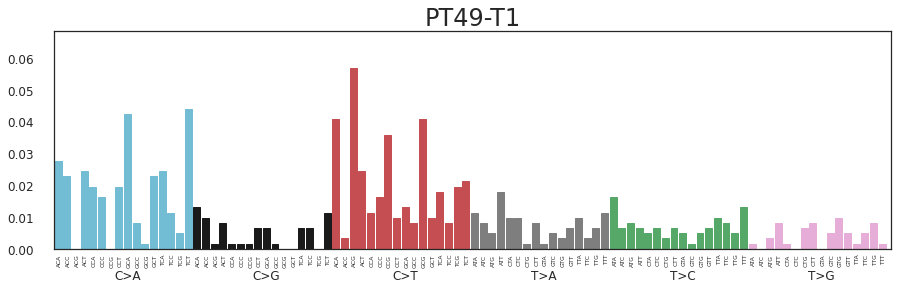

PAUHAZ tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


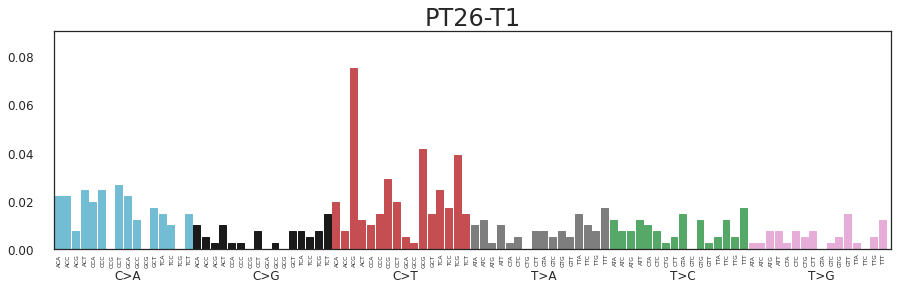

PAUNPA tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


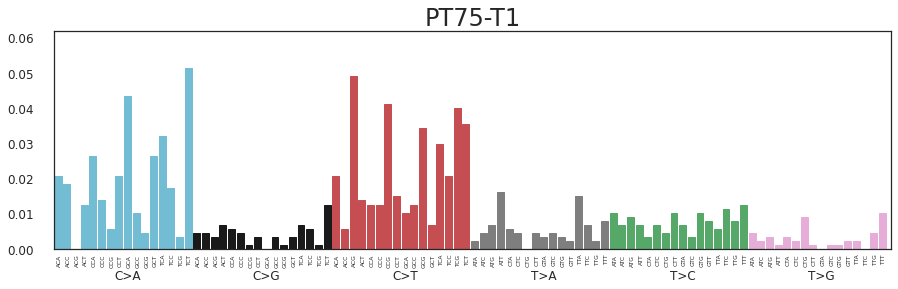

PAVCKS tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


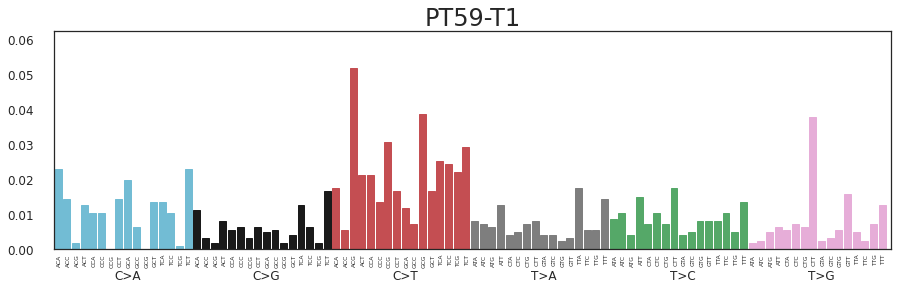

PAVITI tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


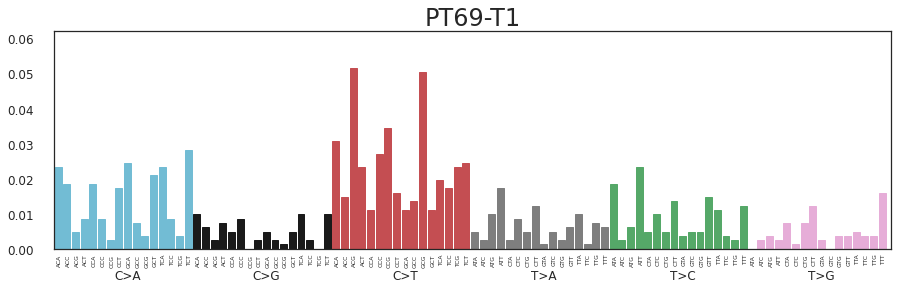

PAVYDM tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


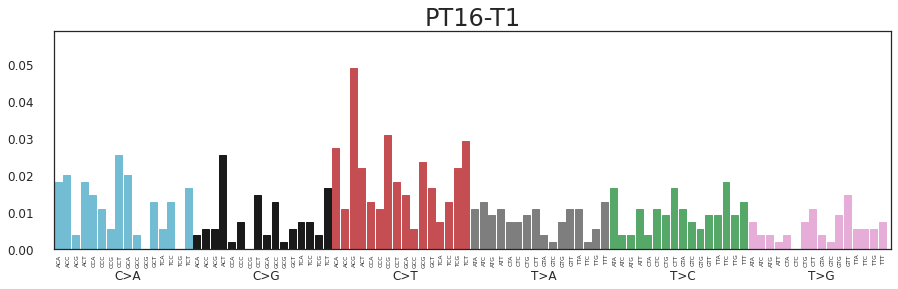

PAVYKD tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


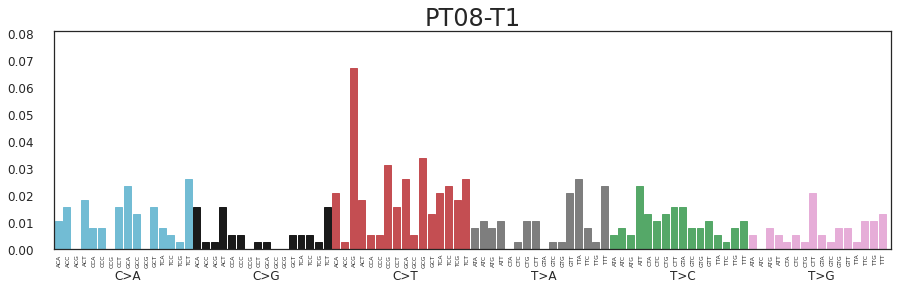

PAWDGA tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


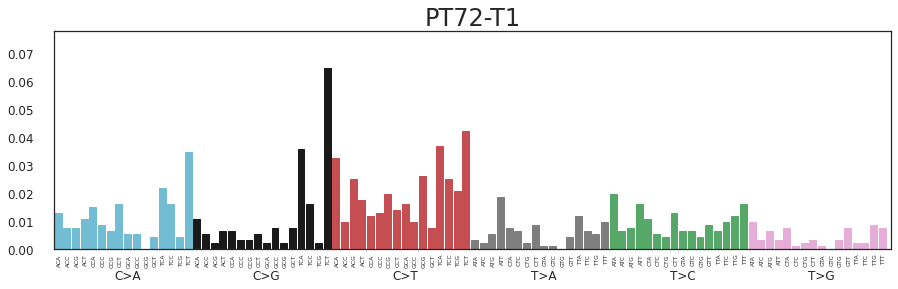

PAWFBL tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


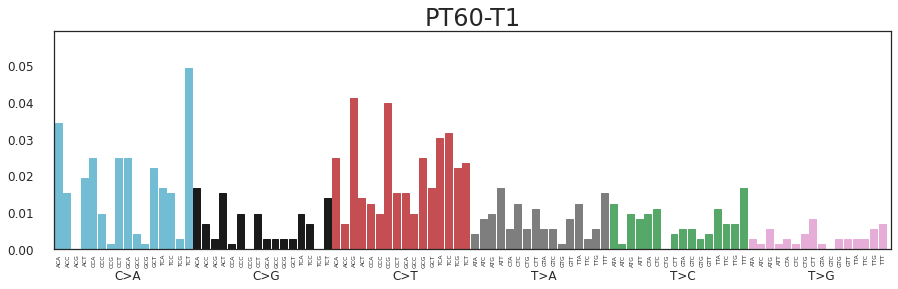

PAWFWK tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


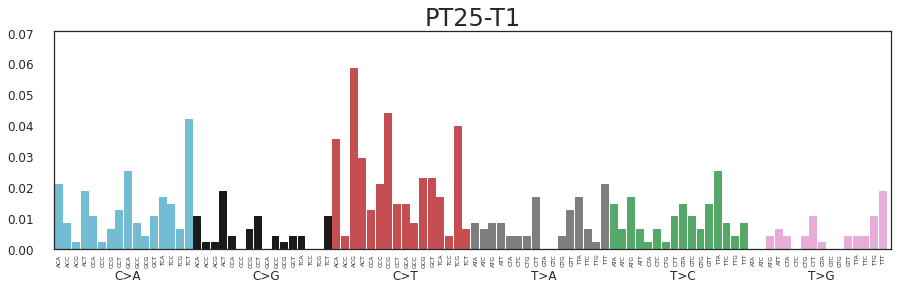

SJ015723 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


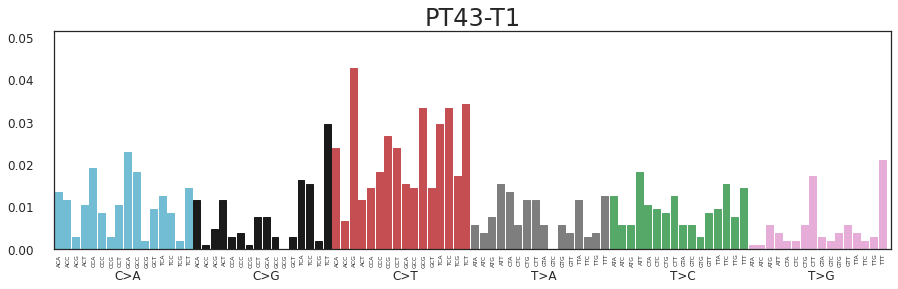

SJ030128 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


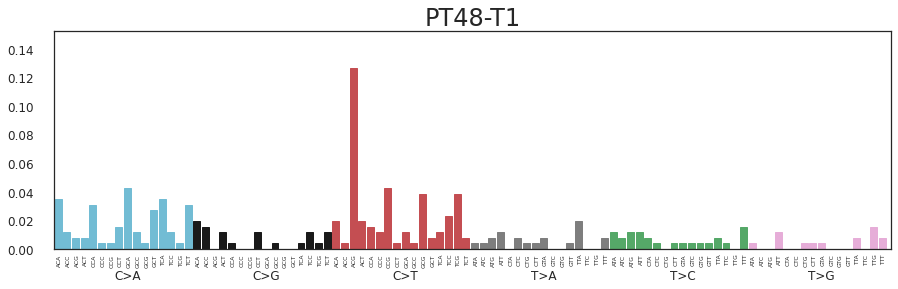

SJ030255 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


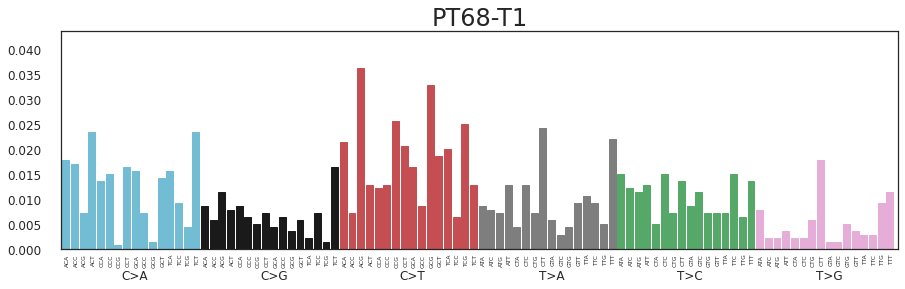

SJ030581 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


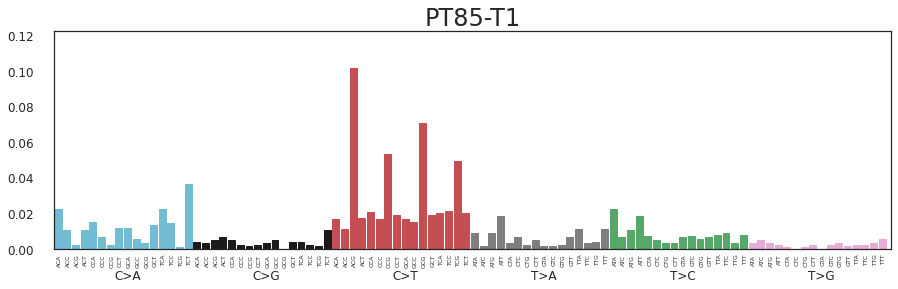

SJ030707 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


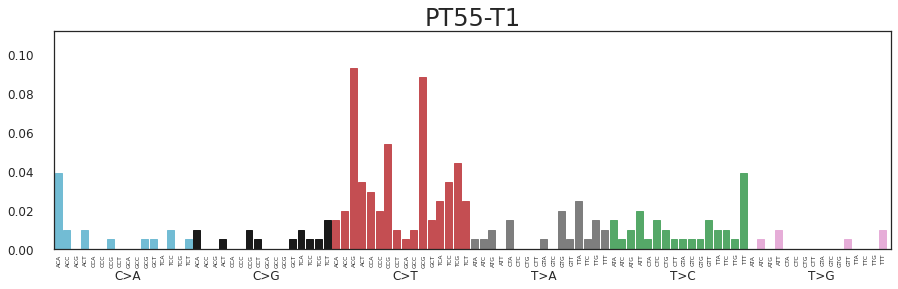

SJ030896 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


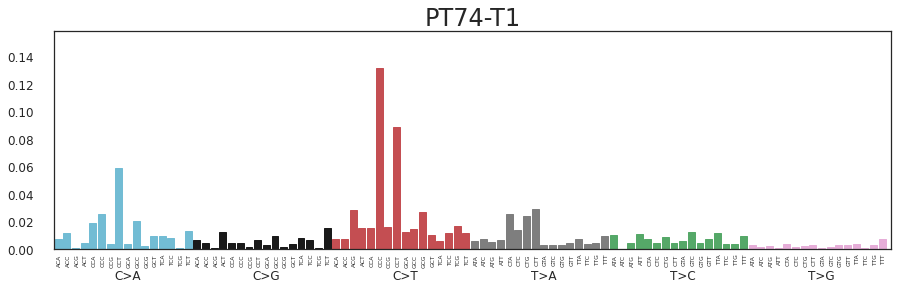

SJ030997 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


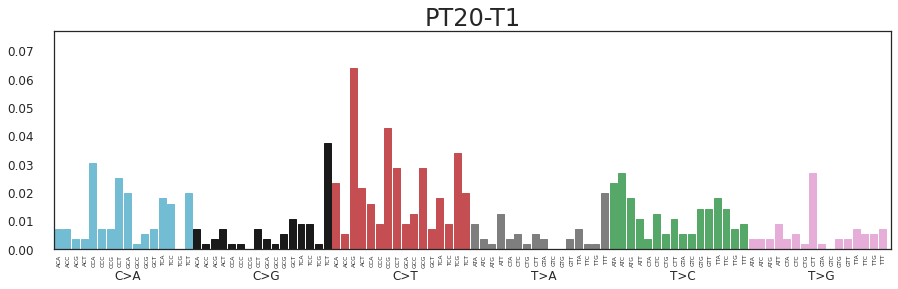

SJ031235 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


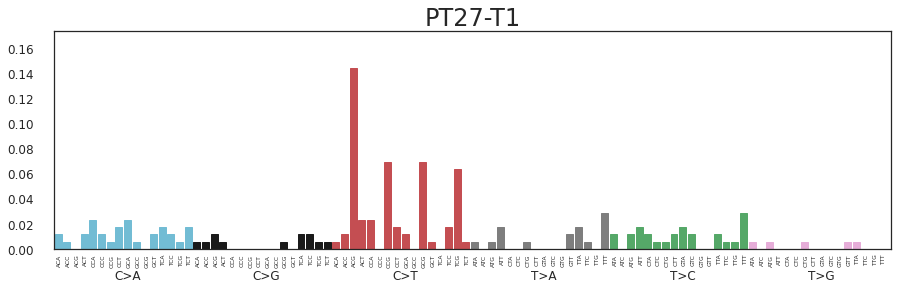

SJ031605 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


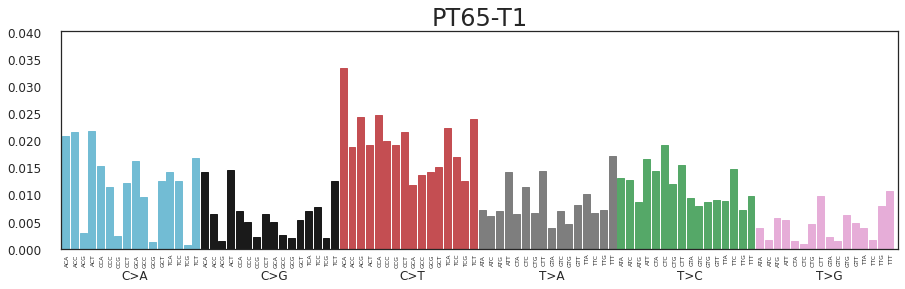

SJ031948 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


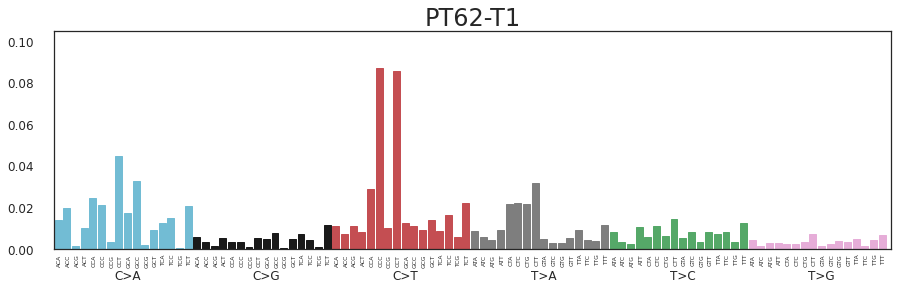

SJ032346 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


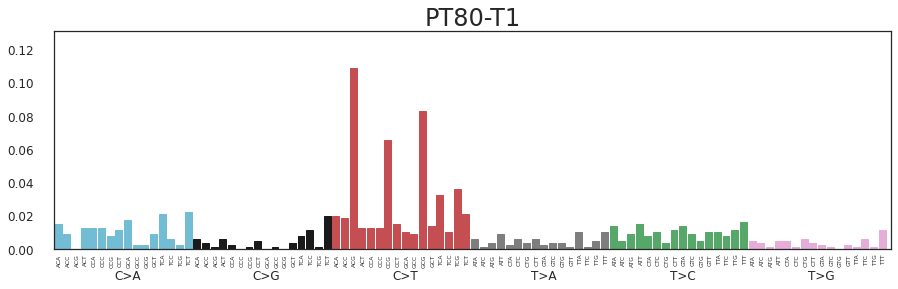

SJ032393 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


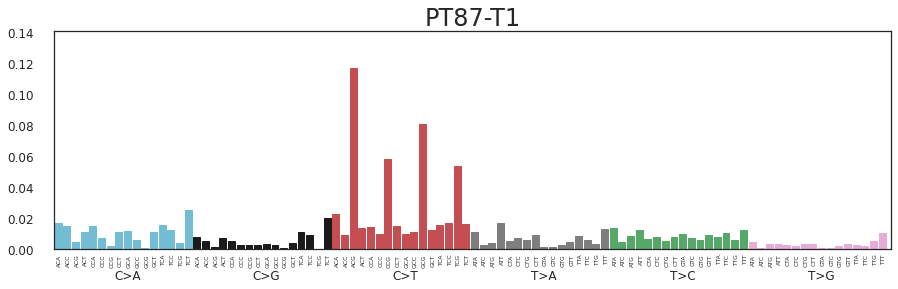

SJ032417 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


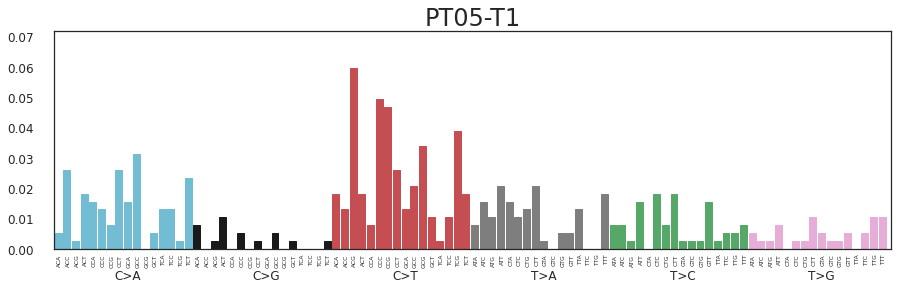

SJ033236 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


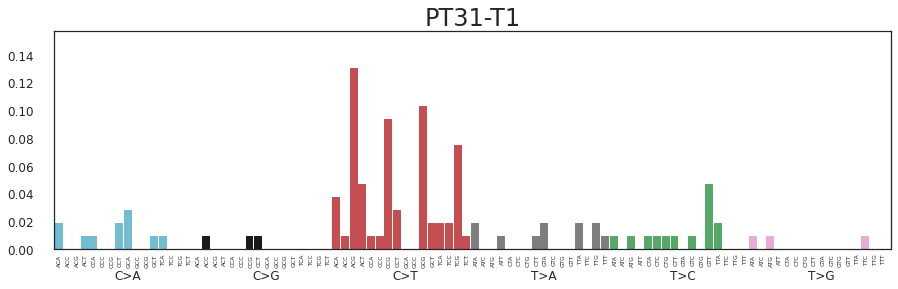

SJ034089 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


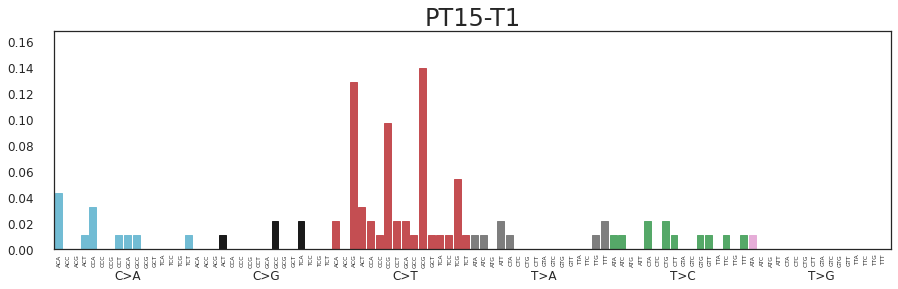

SJ034110 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


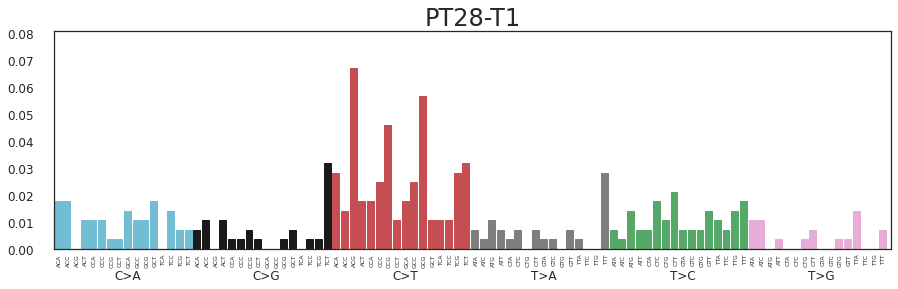

PMC01 tumor1


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


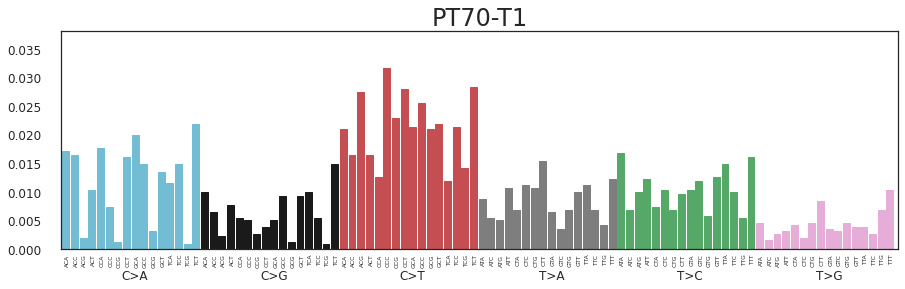

PMC01 tumor2


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


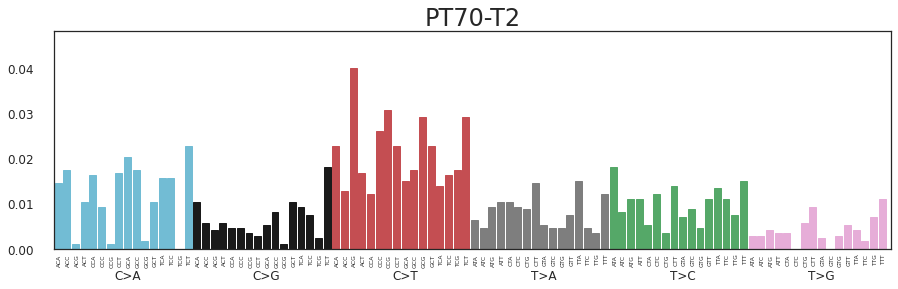

PMC01 tumor3


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


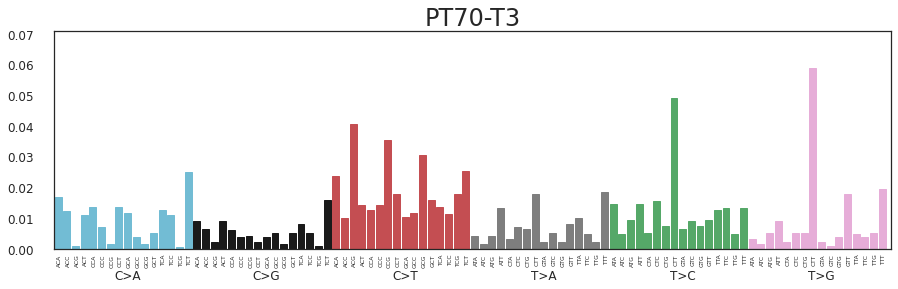

PMC01 tumor4


/tmp/ipykernel_401691/1292774703.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first', inplace=True)


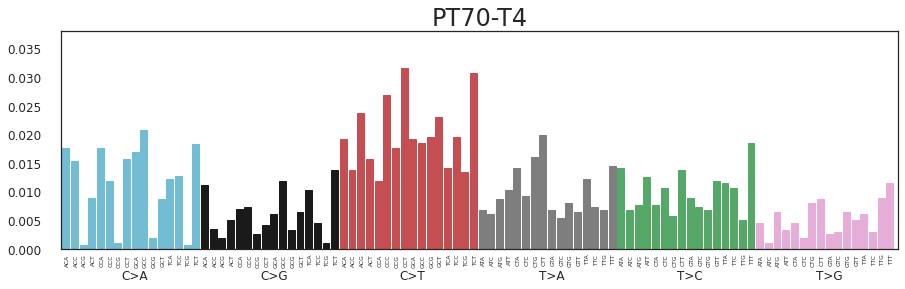

In [9]:
for pt in samples_dict.keys():
    if pt.startswith('pt'):
        cohort = 'sjd'
    elif pt.startswith('PA'):
        cohort = 'target'
    elif pt.startswith('SJ'):
        cohort = 'stjude'
    elif pt.startswith('PMC'):
        cohort = 'pmc'
    else:
        print('Other?', pt)
    
    tumors = samples_dict[pt].keys()
    tumors = [t for t in tumors if t not in ['normal','normal2','clone1','clone2','sex']]
    for tumor in tumors:
        print(pt,tumor)
        tumor_id = samples_dict[pt][tumor]
        normal_id = samples_dict[pt]['normal']

        file = "/process_vep_output/"+tumor_id+"_vs_"+normal_id+".maf.gz"

        df = pd.read_csv("mafs/mafs_"+cohort+"/"+pt+"/"+tumor_id+"_vs_"+normal_id+file, sep='\t')
        df = df[df['mut_type']=='snv']
        df = df[df['gnomADg_AF']<0.001]
        dictionary = df_to_dict(df)
        dict_counts = change_dct_format(dictionary)
        fig, ax = plt.subplots()
        pt_final = samples_final_ids_dict[pt]
        plot_signature(dict_counts, title=pt_final+'-T'+tumor[-1],ax=ax)
        plt.savefig('plots/mut_profiles/'+pt_final+'mut_profile.svg', bbox_inches='tight',format='svg')
        plt.show()